# 03 Wavelength filters, directional cosine, trend removal

Butterworth low pass with cutoff wavelength L and order n:

    H = 1 / (1 + (k / k0)^(2n))      k0 = 2 pi / L

Half power at k0. Higher n gives a sharper cutoff and more ringing; 4 is a
common compromise. High pass is 1 - H. Band pass is the product of a low
pass at the short cutoff and a high pass at the long one. The Gaussian
low pass exp(-(k/k0)^2 / 2) never rings but rolls off slowly.

The directional cosine filter weights the spectrum by

    H = |cos(theta - alpha)|^n

where theta is the azimuth of the wavenumber vector. Linear features
striking at azimuth a have their energy at theta = a + 90, so rejecting
that direction removes them. It also removes that direction from
everything else, so keep n high (narrow wedge) and check what was taken out.

Trend removal fits a polynomial surface by least squares and subtracts it.
Order 1 is a plane; the FFT pipeline already removes a plane fitted to the
grid edges before filtering.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from potfield import read_grid, write_grid, filters, transforms, spectrum, display

DATA = "../data"
OUT = "../outputs"
INC, DEC = -62.4, 7.5   # IGRF inclination, declination (deg) for the Frome area at 2015.0
plt.rcParams["figure.dpi"] = 90

Text(0.5, 1.0, 'low pass, cutoff 5 km')

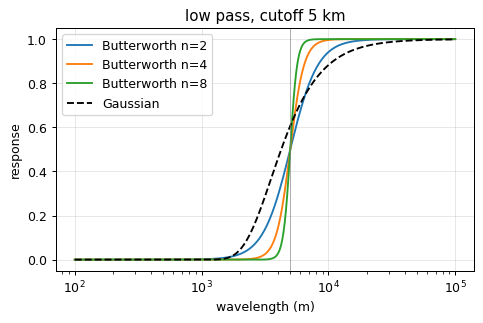

In [2]:
g = read_grid(f"{DATA}/frome_tmi.ers", bounds=(139.30, -30.60, 139.90, -30.10), epsg=28354, units="nT")
wavelength = np.logspace(2, 5, 300); k = 2 * np.pi / wavelength
fig, ax = plt.subplots(figsize=(6, 3.5))
for n in (2, 4, 8):
    ax.semilogx(wavelength, filters.butterworth_lowpass_response(k, 5000, n), label=f"Butterworth n={n}")
ax.semilogx(wavelength, filters.gaussian_lowpass_response(k, 5000), "k--", label="Gaussian")
ax.axvline(5000, color="gray", lw=0.5)
ax.set_xlabel("wavelength (m)"); ax.set_ylabel("response"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("low pass, cutoff 5 km")

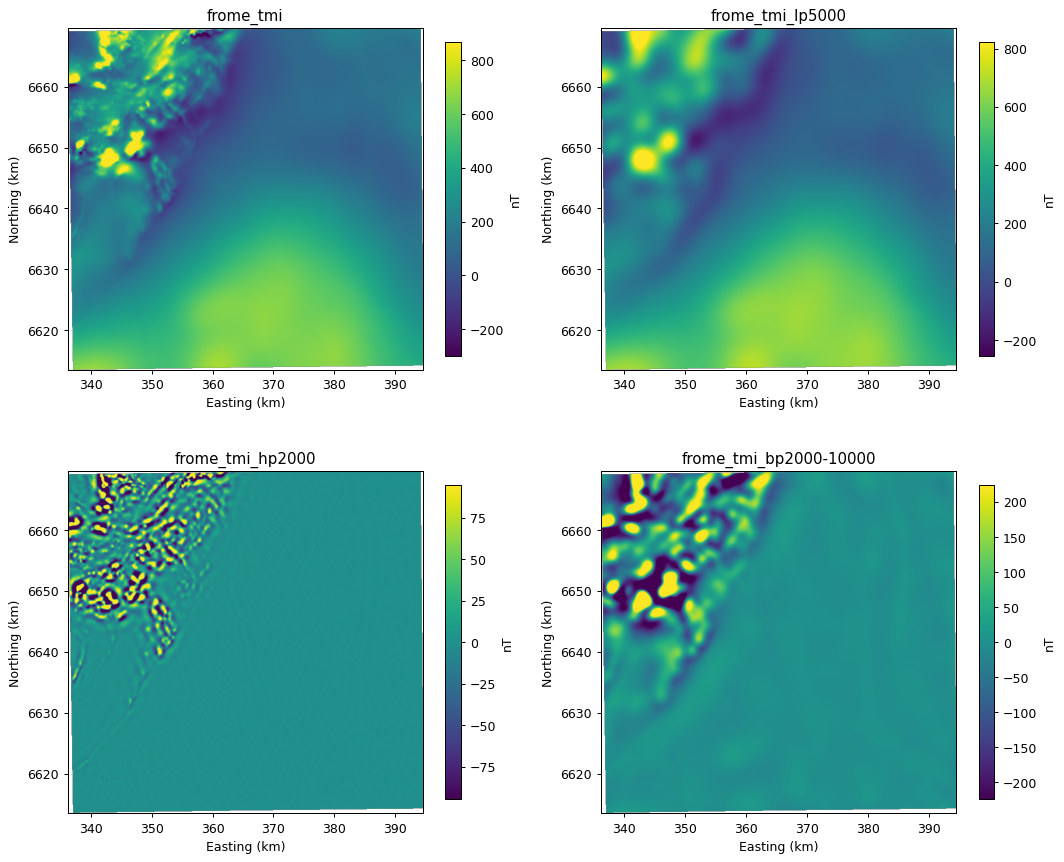

In [3]:
lp = filters.butterworth_lowpass(g, 5000)
hp = filters.butterworth_highpass(g, 2000)
bp = filters.bandpass(g, long_wavelength=10000, short_wavelength=2000)
fig, axes = display.compare([g, lp, hp, bp], ncols=2, cmap="viridis", clip=("std", 2.5))

## Directional cosine on synthetic stripes

Flight-line noise in a compiled grid is usually faint. To see what the
filter does, add north-south stripes with a 400 m wavelength and remove
them. Compare the removed part with the original to judge collateral
damage.

stripe RMS in: 16.513526409537803  residual after filter vs original: 82.77075768098058


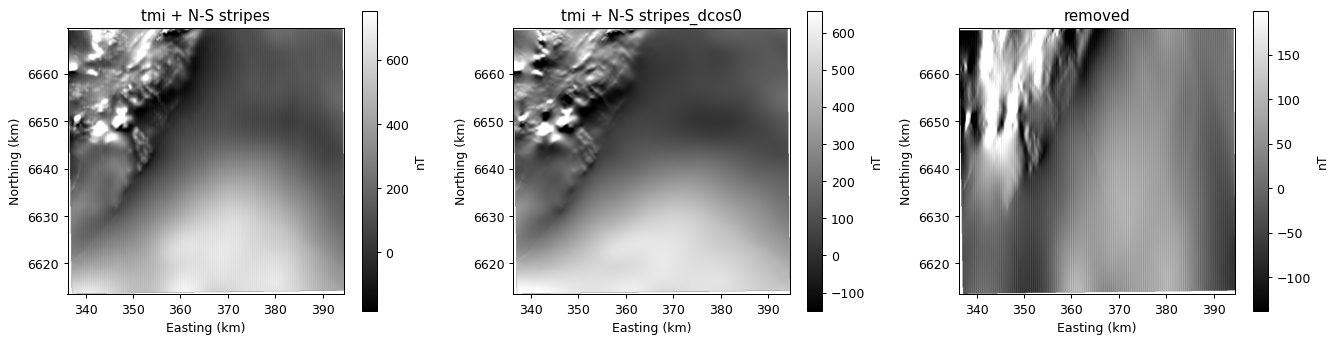

In [4]:
xx, yy = np.meshgrid(g.x, g.y)
stripes = 0.1 * np.nanstd(g.values) * np.sin(2 * np.pi * xx / 400)
noisy = g.with_values(g.values + stripes, name="tmi + N-S stripes")
clean = filters.directional_cosine(noisy, azimuth=0, degree=8)
removed = noisy.with_values(noisy.values - clean.values, name="removed")
fig, axes = display.compare([noisy, clean, removed], ncols=3, cmap="gray", clip=("std", 2.0), figsize_per=(5, 4.5))
print("stripe RMS in:", np.nanstd(stripes), " residual after filter vs original:", np.nanstd(clean.values - g.values))

## Trend removal on the Bouguer gravity

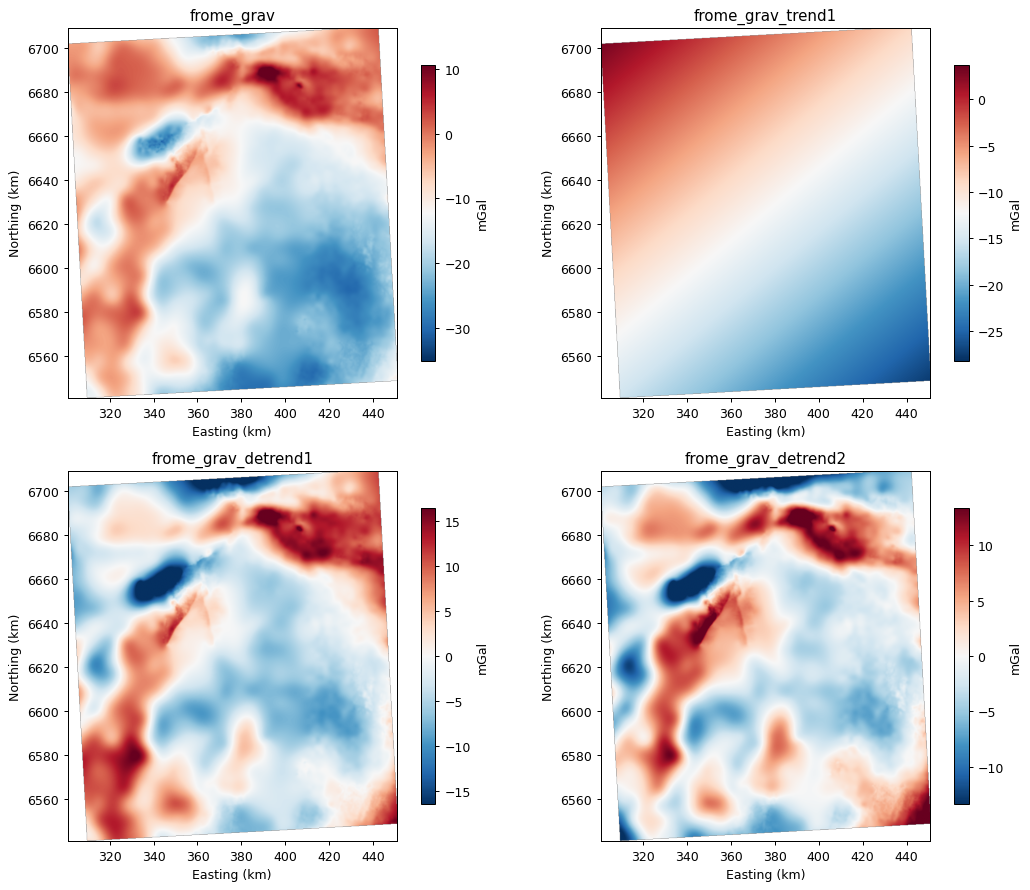

In [5]:
cba = read_grid(f"{DATA}/frome_grav.ers", epsg=28354, units="mGal")
resid1, trend1 = filters.remove_trend(cba, order=1)
resid2, trend2 = filters.remove_trend(cba, order=2)
fig, axes = display.compare([cba, trend1, resid1, resid2], ncols=2, cmap="RdBu_r", clip=("std", 2.5))